In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv("21-housing.csv")

In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [7]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

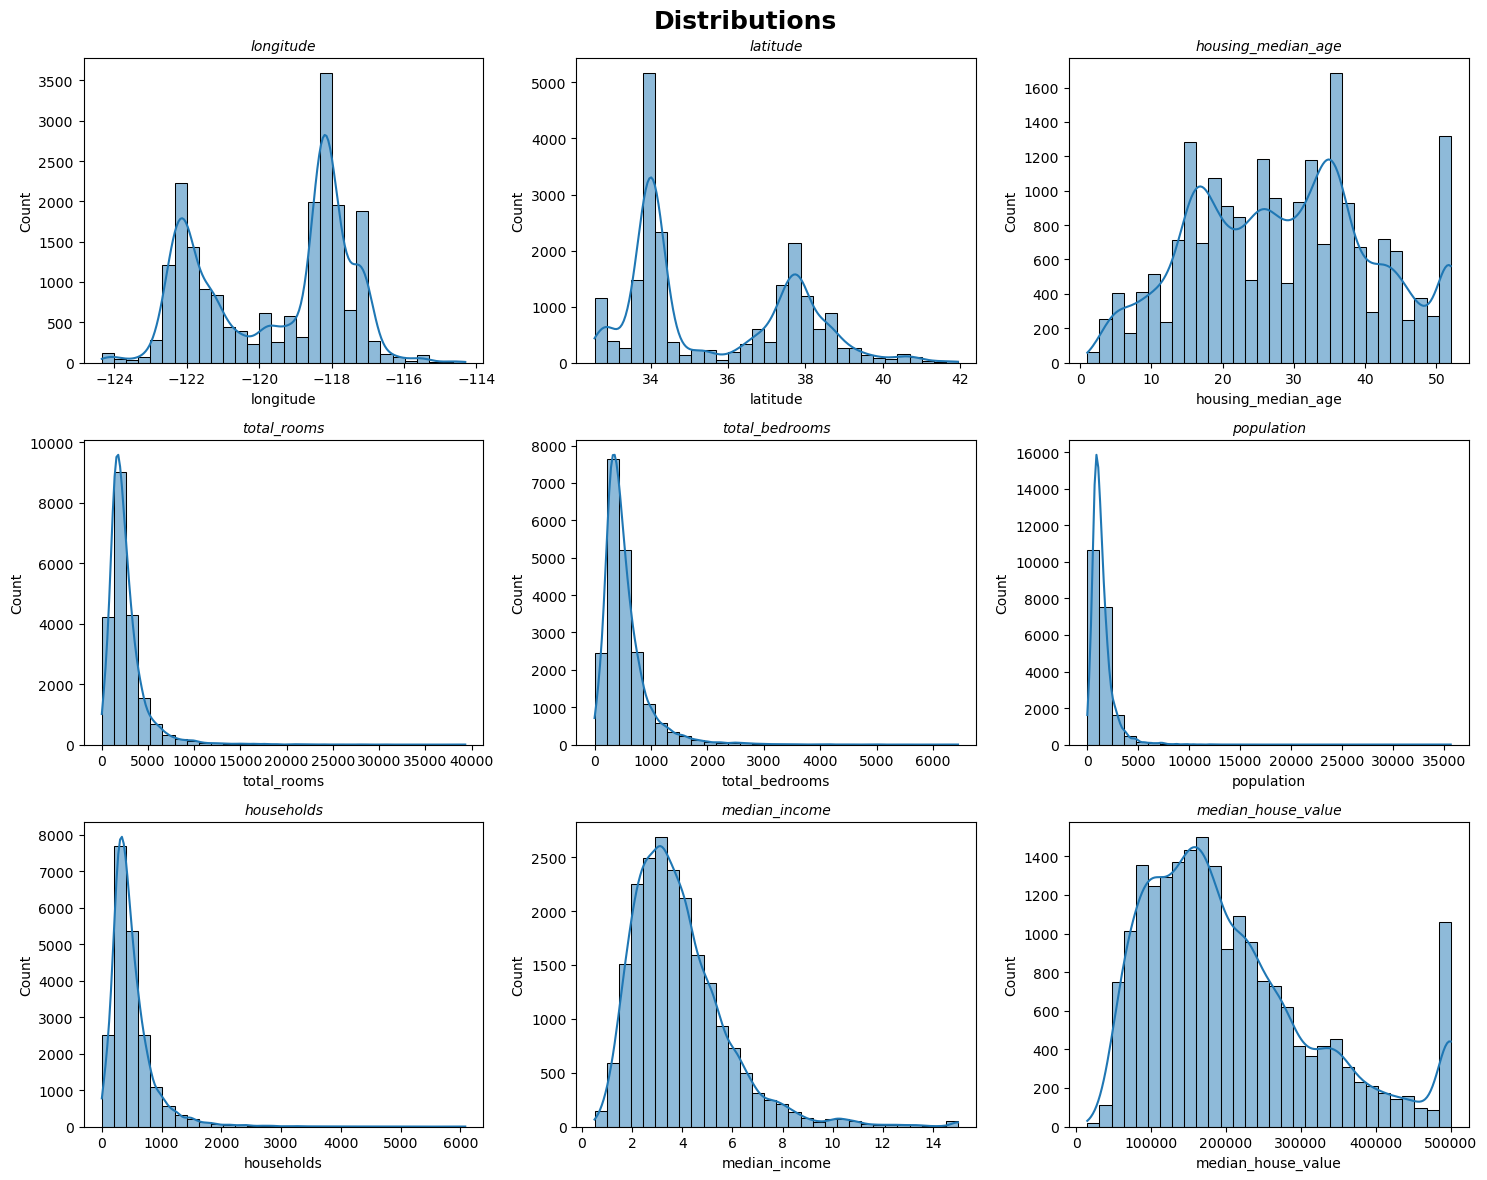

In [8]:
columns = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value']
fig, axes = plt.subplots(nrows=3,ncols=3,figsize=(15,12))
fig.suptitle("Distributions", fontsize=18,fontweight="black")

for i, col in enumerate(columns):
    row = i // 3
    col_idx = i % 3
    ax = axes[row,col_idx]
    sns.histplot(data=df,x=col,kde=True,ax=ax,bins=30)
    ax.set_title(col,fontsize=10,fontstyle="italic")
    
plt.tight_layout()
plt.show()

In [9]:
df.corr(numeric_only=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


In [10]:
def fin_outliers_iqr(df,threshold=1.5):
    outlier_summary = {}

    numeric_cols = df.select_dtypes(include=["float64","int64"]).columns
   
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        outlier_summary[col] = {
            "outlier_count" : outliers.shape[0],
            "outlier_percentage" : 100 * outliers.shape[0] / df.shape[0],
            "lower_bound" : lower_bound,
            "upper_bound" : upper_bound
        }

    return pd.DataFrame(outlier_summary)

In [11]:
fin_outliers_iqr(df,threshold=1.5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
outlier_count,0.000,0.00,0.0,1287.000000,1271.000000,1196.000000,1220.000000,681.000000,1071.000000
outlier_percentage,0.000,0.00,0.0,6.235465,6.157946,5.794574,5.910853,3.299419,5.188953
lower_bound,-127.485,28.26,-10.5,-1102.625000,-230.500000,-620.000000,-207.500000,-0.706375,-98087.500000
upper_bound,-112.325,43.38,65.5,5698.375000,1173.500000,3132.000000,1092.500000,8.013025,482412.500000


In [12]:
def remove_outliers_from_column(df,target_col,threshold=1.5):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR

    return df[(df[col] >= lower_bound) & (df[col] <=upper_bound)]

In [13]:
print("Original data shape: ", df.shape)
df_target_clean = remove_outliers_from_column(df,"median_house_value")
print("Only target column cleaning shape: ",df_target_clean.shape)

Original data shape:  (20640, 10)
Only target column cleaning shape:  (19569, 10)


In [14]:
df_target_clean.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,19569.000000,19569.000000,19569.000000,19569.000000,19369.000000,19569.000000,19569.000000,19569.000000,19569.000000
mean,-119.562786,35.654159,28.352752,2619.977260,539.893335,1442.788952,501.394859,3.665568,190852.301906
std,2.005764,2.151007,12.497772,2183.419302,422.650225,1145.011369,383.396308,1.557927,95438.555669
min,-124.350000,32.540000,1.000000,2.000000,2.000000,3.000000,2.000000,0.499900,14999.000000
25%,-121.760000,33.930000,18.000000,1438.000000,297.000000,797.000000,282.000000,2.522700,116200.000000
50%,-118.510000,34.270000,28.000000,2110.000000,437.000000,1181.000000,411.000000,3.441200,173200.000000
75%,-117.990000,37.730000,37.000000,3123.000000,648.000000,1749.000000,606.000000,4.572100,246700.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,482200.000000


In [15]:
df_target_clean["total_bedrooms"] = df_target_clean["total_bedrooms"].fillna(df_target_clean["total_bedrooms"].median())

C:\Users\rarsl\AppData\Local\Temp\ipykernel_16620\3688706348.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_target_clean["total_bedrooms"] = df_target_clean["total_bedrooms"].fillna(df_target_clean["total_bedrooms"].median())


In [16]:
df_target_clean.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [17]:
df_target_clean = pd.get_dummies(df_target_clean,columns=["ocean_proximity"],drop_first=True,dtype=int)

In [18]:
df_target_clean.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,1,0


In [19]:
# Ev başına düşen oda sayısı
df_target_clean["rooms_per_housing"] = df_target_clean["total_rooms"] / df_target_clean["households"]
# Odaların kaç tanesi yatak odası
# Düşük oran -> geniş ev
df_target_clean["bedrooms_per_rooms"] = df_target_clean["total_bedrooms"] / df_target_clean["total_rooms"]
# Ev başına düşen kişi sayısı
# Yüksek oran -> kalabalık mahalle
df_target_clean["population_per_rooms"] = df_target_clean["population"] / df_target_clean["total_rooms"]

In [20]:
df_target_clean.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_housing,bedrooms_per_rooms,population_per_rooms
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,1,0,6.984127,0.146591,0.365909
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,1,0,6.238137,0.155797,0.338217
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,1,0,8.288136,0.129516,0.338105
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,1,0,5.817352,0.184458,0.437991
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,1,0,6.281853,0.172096,0.347265


In [21]:
df_target_clean.corr()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_housing,bedrooms_per_rooms,population_per_rooms
longitude,1.000000,-0.924031,-0.101691,0.044735,0.070037,0.101638,0.056346,-0.010808,-0.047342,-0.061842,0.009635,-0.461906,0.049731,-0.029953,0.083633,0.005080
latitude,-0.924031,1.000000,0.006104,-0.033798,-0.068086,-0.114359,-0.073547,-0.076249,-0.149100,0.357002,-0.017066,0.345417,-0.164973,0.122028,-0.109949,-0.005534
housing_median_age,-0.101691,0.006104,1.000000,-0.372715,-0.326660,-0.294893,-0.310343,-0.197628,0.061480,-0.232034,0.017969,0.244345,0.025762,-0.180722,0.153854,0.025648
total_rooms,0.044735,-0.033798,-0.372715,1.000000,0.930908,0.859642,0.921278,0.226557,0.147526,0.032285,-0.007654,-0.021791,-0.013937,0.145878,-0.189541,-0.032633
total_bedrooms,0.070037,-0.068086,-0.326660,0.930908,1.000000,0.874977,0.973576,0.024580,0.078096,-0.007962,-0.004502,-0.019202,0.002915,0.015801,0.059694,-0.023026
population,0.101638,-0.114359,-0.294893,0.859642,0.874977,1.000000,0.909218,0.045413,0.017764,-0.030341,-0.010818,-0.057416,-0.021719,-0.068318,0.000212,0.061205
households,0.056346,-0.073547,-0.310343,0.921278,0.973576,0.909218,1.000000,0.049055,0.099352,-0.042466,-0.009374,-0.009455,0.004377,-0.075319,0.022005,-0.020196
median_income,-0.010808,-0.076249,-0.197628,0.226557,0.024580,0.045413,0.049055,1.000000,0.644267,-0.217488,-0.009453,0.048560,-0.005032,0.323655,-0.548628,-0.002180
median_house_value,-0.047342,-0.149100,0.061480,0.147526,0.078096,0.017764,0.099352,0.644267,1.000000,-0.502702,0.031758,0.156396,0.133403,0.108223,-0.195921,-0.028706
ocean_proximity_INLAND,-0.061842,0.357002,-0.232034,0.032285,-0.007962,-0.030341,-0.042466,-0.217488,-0.502702,1.000000,-0.011299,-0.243351,-0.265443,0.182169,-0.119387,0.001282


In [22]:
X = df_target_clean.drop("median_house_value",axis=1)
y = df_target_clean["median_house_value"]

In [23]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=0)

In [24]:
def correlation_for_dropping(df, threshold):
    columns_to_drop = set()
    corr = df_target_clean.corr()
    for i in range(len(corr.columns)):
        for j in range(i):
            if abs(corr.iloc[i, j]) > threshold:
                colname = corr.columns[i]
                columns_to_drop.add(colname)
    return columns_to_drop

In [25]:
correlation_for_dropping(X_train, 0.80)

{'households', 'latitude', 'population', 'total_bedrooms'}

In [26]:
from sklearn.preprocessing import PowerTransformer

In [27]:
# 'longitude' sütununda negatif değerler olduğu için uygun olan yeo-johnson metodu 

In [28]:
pt = PowerTransformer(method="yeo-johnson")

In [29]:
X_train_transformed = pt.fit_transform(X_train)
X_test_transformed = pt.transform(X_test)

In [30]:
df_target_clean.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN', 'rooms_per_housing', 'bedrooms_per_rooms',
       'population_per_rooms'],
      dtype='object')

In [31]:
df_target_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19569 entries, 0 to 20639
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   19569 non-null  float64
 1   latitude                    19569 non-null  float64
 2   housing_median_age          19569 non-null  float64
 3   total_rooms                 19569 non-null  float64
 4   total_bedrooms              19569 non-null  float64
 5   population                  19569 non-null  float64
 6   households                  19569 non-null  float64
 7   median_income               19569 non-null  float64
 8   median_house_value          19569 non-null  float64
 9   ocean_proximity_INLAND      19569 non-null  int64  
 10  ocean_proximity_ISLAND      19569 non-null  int64  
 11  ocean_proximity_NEAR BAY    19569 non-null  int64  
 12  ocean_proximity_NEAR OCEAN  19569 non-null  int64  
 13  rooms_per_housing           19569 no

In [32]:
columns_target = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
        'total_bedrooms', 'population', 'households', 'median_income',
        'ocean_proximity_INLAND',
        'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
        'ocean_proximity_NEAR OCEAN', 'rooms_per_housing', 'bedrooms_per_rooms',
        'population_per_rooms']

In [33]:
df_target_clean.shape

(19569, 16)

In [34]:
X_train_transformed_df = pd.DataFrame(X_train_transformed,columns=columns_target)

In [35]:
import math

def plot_all_histograms(df, title_prefix=""):
    num_cols = columns_target
    n_cols = 4
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(12,12))

    for i, col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"{title_prefix}{col}")
        plt.xlabel("")
        plt.ylabel("")

    plt.tight_layout()
    plt.show()

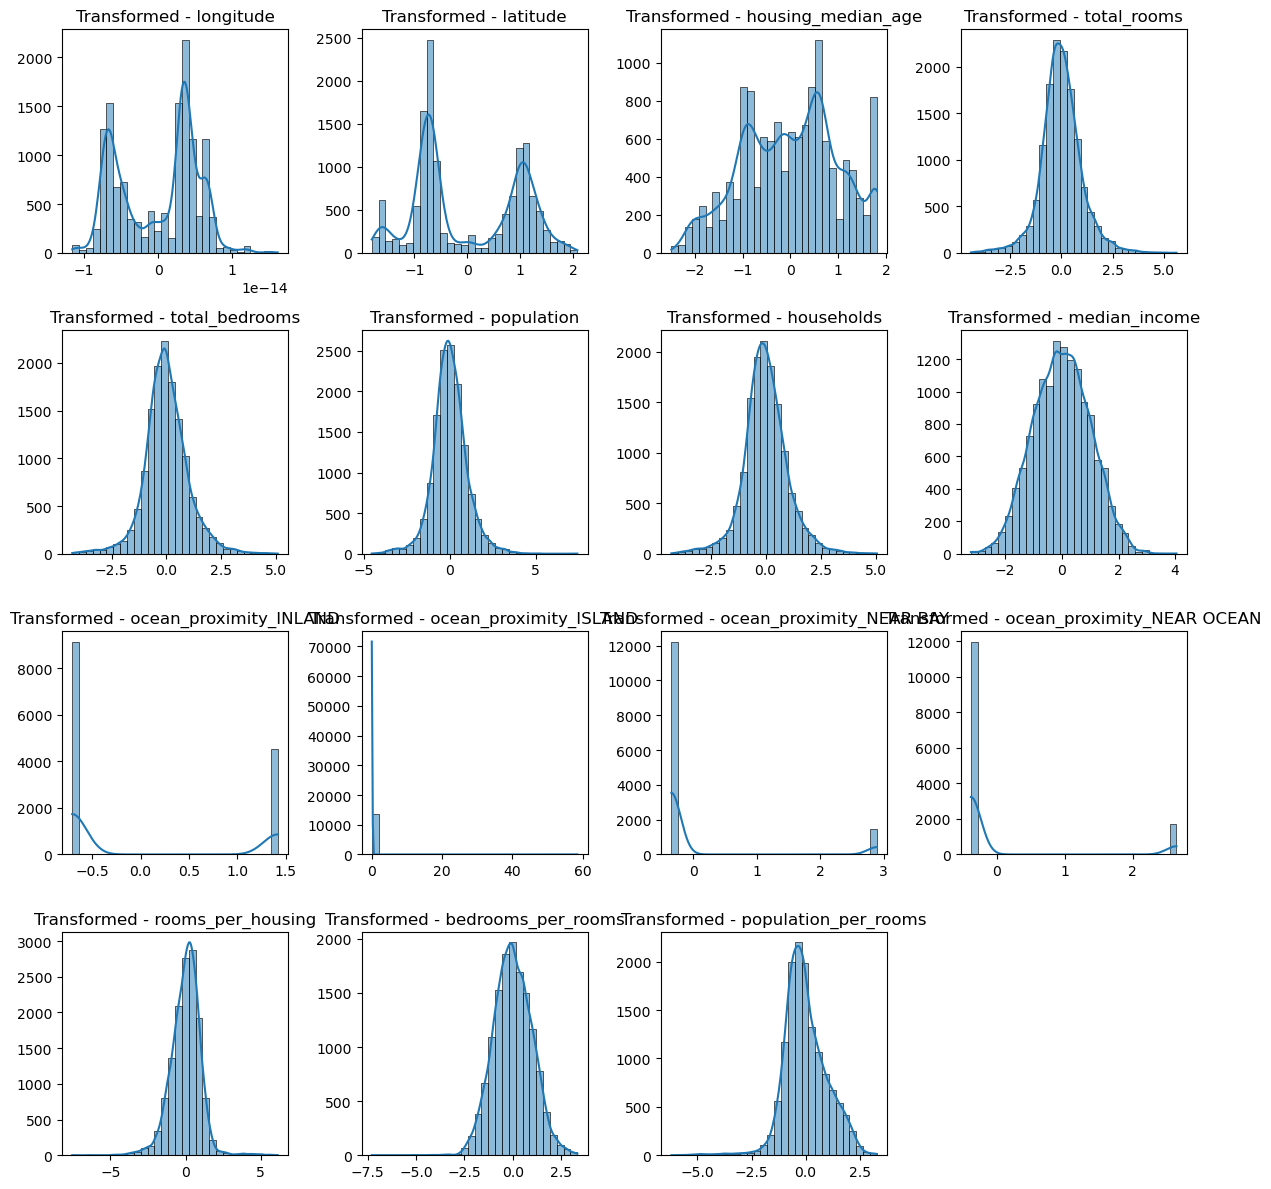

In [36]:
plot_all_histograms(X_train_transformed_df,title_prefix="Transformed - ")

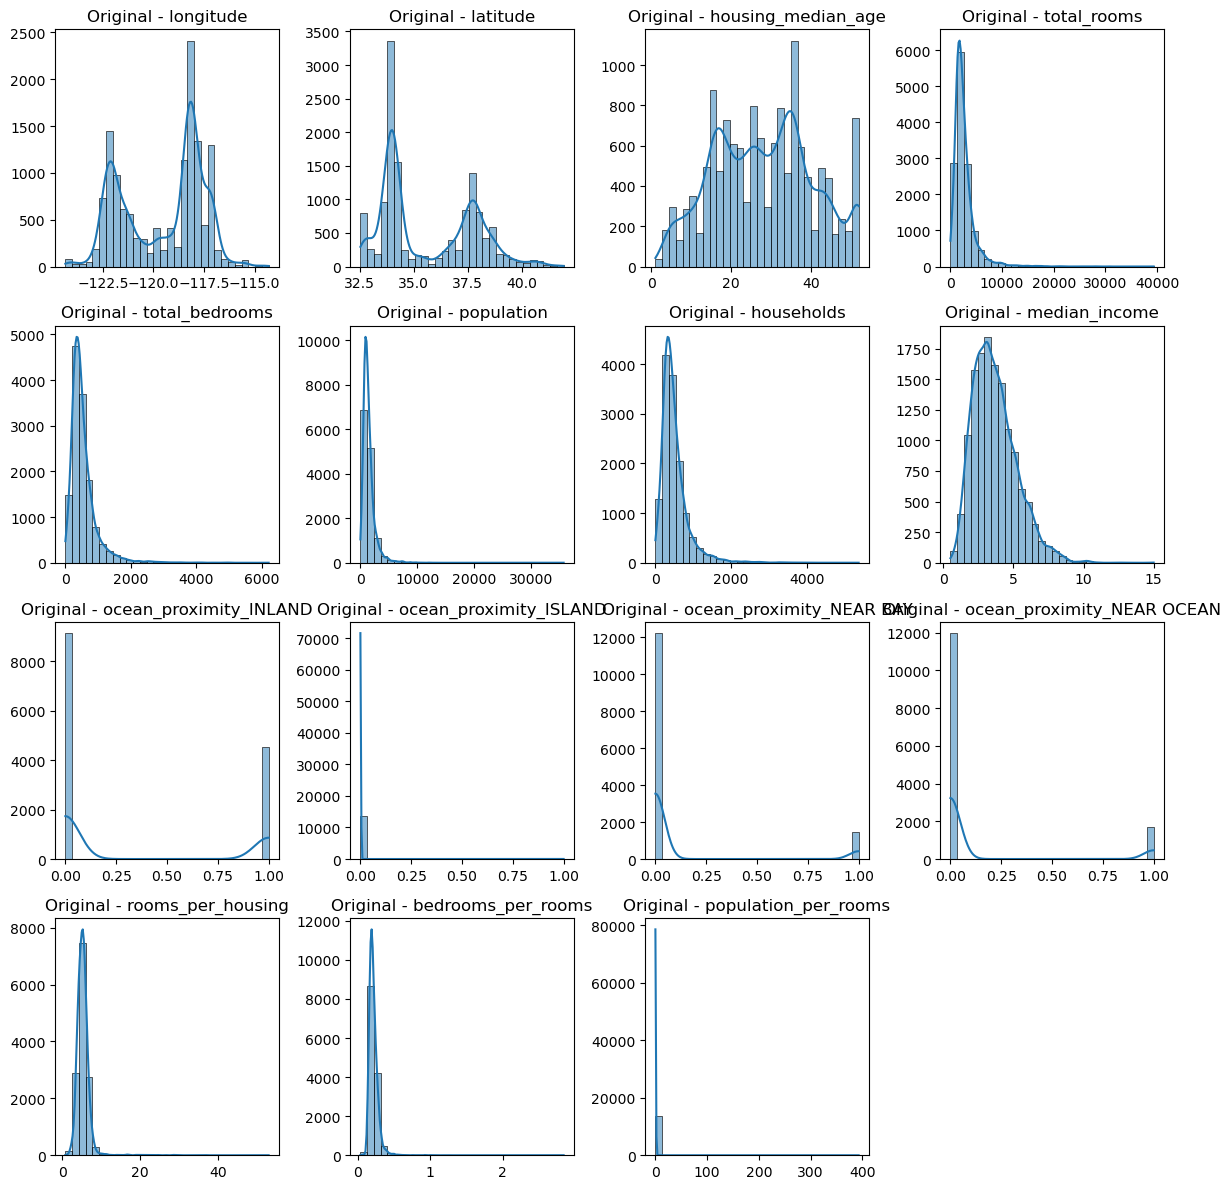

In [37]:
plot_all_histograms(X_train,title_prefix="Original - ")

In [38]:
def plot_compare_histograms(original,transformed,title_prefix=""):
    cols = columns_target
    n_rows = len(cols)

    plt.figure(figsize=(10,4*n_rows))
    for i, col in enumerate(cols):
        plt.subplot(n_rows,2,2*i+1)
        sns.histplot(original[col],kde=True,bins=30)
        plt.title(f"Original - {col}")
        plt.xlabel("")
        plt.ylabel("")

        plt.subplot(n_rows,2,2*i+2)
        sns.histplot(transformed[col],kde=True,bins=30)
        plt.title(f"Transformed - {col}")
        plt.xlabel("")
        plt.ylabel("")
        
    plt.tight_layout()
    plt.show()

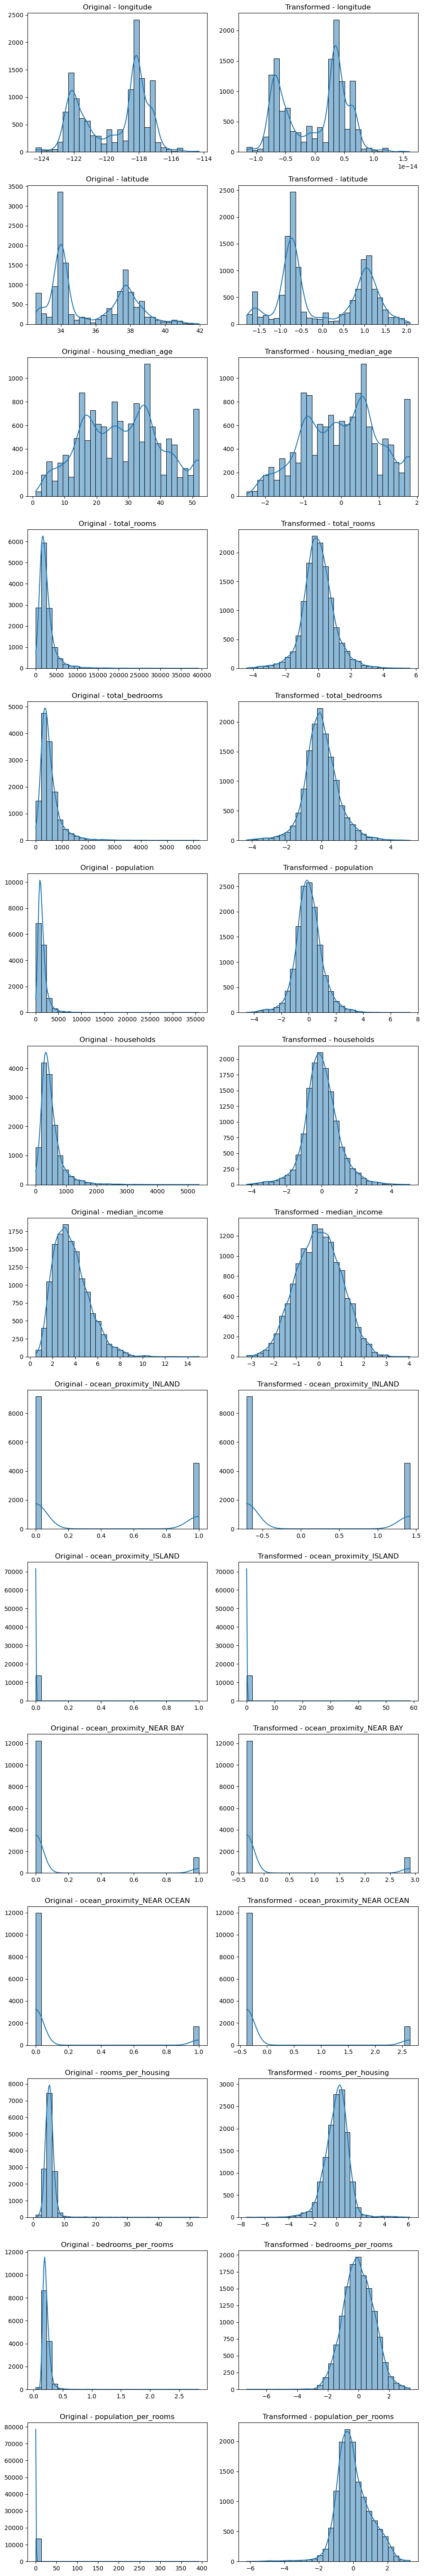

In [39]:
plot_compare_histograms(X_train,X_train_transformed_df)

In [40]:
from scipy.stats import boxcox
y_train_transformed, lambda_y = boxcox(y_train)

In [41]:
from sklearn.linear_model import LinearRegression

In [42]:
model = LinearRegression()
model.fit(X_train_transformed,y_train_transformed)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [43]:
y_pred_transformed = model.predict(X_test_transformed)

def inverse_boxcox(y, lambda_):
    if lambda_ == 0:
        return np.exp(y)
    else:
        return np.power(y * lambda_ + 1, 1 / lambda_)

y_pred_original = inverse_boxcox(y_pred_transformed, lambda_y)

In [44]:
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error

In [45]:
print("R2 Score: ",r2_score(y_test,y_pred_original))
print("Mean Absolute Error: ",mean_absolute_error(y_test,y_pred_original))
print("Mean Squared Error",mean_squared_error(y_test,y_pred_original))
print("RMSE: ",np.sqrt(mean_squared_error(y_test,y_pred_original)))

R2 Score:  0.62773208717672
Mean Absolute Error:  41486.91264003586
Mean Squared Error 3397226708.2939796
RMSE:  58285.73331694455


In [46]:
model2 = LinearRegression()

In [47]:
model2.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [48]:
y_pred = model2.predict(X_test)

In [49]:
print("R2 Score: ",r2_score(y_test,y_pred))
print("Mean Absolute Error: ",mean_absolute_error(y_test,y_pred))
print("Mean Squared Error",mean_squared_error(y_test,y_pred))
print("RMSE: ",np.sqrt(mean_squared_error(y_test,y_pred)))

R2 Score:  0.6233680677382774
Mean Absolute Error:  43262.127366945286
Mean Squared Error 3437051691.54154
RMSE:  58626.3736857529


In [50]:
import lightgbm as lgb

In [51]:
lgbr = lgb.LGBMRegressor(verbosity=-1)
lgbr.fit(X_train_transformed_df,y_train_transformed)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [52]:
X_test_transformed_df = pd.DataFrame(X_test_transformed,columns=columns_target)

In [53]:
y_pred_lgb_transformed = lgbr.predict(X_test_transformed_df)

In [54]:
y_pred_lgb = inverse_boxcox(y_pred_lgb_transformed,lambda_y)

In [55]:
print("R2 Score: ",r2_score(y_test,y_pred_lgb))
print("Mean Absolute Error: ",mean_absolute_error(y_test,y_pred_lgb))
print("Mean Squared Error",mean_squared_error(y_test,y_pred_lgb))
print("RMSE: ",np.sqrt(mean_squared_error(y_test,y_pred_lgb)))

R2 Score:  0.8103079685804382
Mean Absolute Error:  27819.318794894712
Mean Squared Error 1731083483.9396787
RMSE:  41606.29139853345


In [56]:
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
import lightgbm as lgb

In [57]:
models = {
    "Linear Regression" : LinearRegression(),
    "Lasso" : Lasso(),
    "Ridge" : Ridge(),
    "K Neighbors Regressor" : KNeighborsRegressor(),
    "Decision Tree" : DecisionTreeRegressor(),
    "Random Forest Regressor" : RandomForestRegressor(),
    "Adaboost Regressor" : AdaBoostRegressor(),
    "Gradient Boost Regressor" : GradientBoostingRegressor(),
    "XGBoost Regressor" : XGBRegressor(),
    "LighGBM Regressor" : lgb.LGBMRegressor(verbosity=-1)
}

In [58]:
def compare_models(X_train_df, X_test_df, y_train_transformed, y_test, lambda_y=None):
    
    for name, model in models.items():
        model.fit(X_train_df, y_train_transformed)
        y_pred_transformed = model.predict(X_test_df)
        y_pred = inverse_boxcox(y_pred_transformed, lambda_y)
        
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        print(f"--- {name} ---")
        print(f"R2 Score: {r2:.4f}")
        print(f"Mean Absolute Error: {mae:.2f}")
        print(f"Root Mean Squared Error: {rmse:.2f}")
        print("\n")

In [59]:
X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=columns_target)
X_test_transformed_df  = pd.DataFrame(X_test_transformed, columns=columns_target)

compare_models(
    X_train_df=X_train_transformed_df,
    X_test_df=X_test_transformed_df,
    y_train_transformed=y_train_transformed,
    y_test=y_test,
    lambda_y=lambda_y
)

--- Linear Regression ---
R2 Score: 0.6277
Mean Absolute Error: 41486.91
Root Mean Squared Error: 58285.73


--- Lasso ---
R2 Score: 0.5302
Mean Absolute Error: 47117.75
Root Mean Squared Error: 65474.07


--- Ridge ---
R2 Score: 0.6277
Mean Absolute Error: 41488.30
Root Mean Squared Error: 58284.98


--- K Neighbors Regressor ---
R2 Score: 0.6728
Mean Absolute Error: 37427.63
Root Mean Squared Error: 54643.39


--- Decision Tree ---
R2 Score: 0.5858
Mean Absolute Error: 40994.60
Root Mean Squared Error: 61479.51


--- Random Forest Regressor ---
R2 Score: 0.7899
Mean Absolute Error: 28740.38
Root Mean Squared Error: 43788.80


--- Adaboost Regressor ---
R2 Score: 0.5527
Mean Absolute Error: 48255.89
Root Mean Squared Error: 63888.02


--- Gradient Boost Regressor ---
R2 Score: 0.7440
Mean Absolute Error: 33435.84
Root Mean Squared Error: 48337.54


--- XGBoost Regressor ---
R2 Score: 0.8108
Mean Absolute Error: 27727.03
Root Mean Squared Error: 41552.74


--- LighGBM Regressor ---
R2 

In [60]:
xgboost_params = {
    "learning_rate": [0.1, 0.05, 0.01],
    "max_depth": [5,8,12],
    "n_estimators": [100, 200, 300, 500],
    "colsample_bytree": [0.3, 0.5, 0.7, 1],
    "subsample": [0.6, 0.8, 1],
    "min_child_weight": [1,3,5],
    "gamma": [0,0.1,0.3],
    "reg_alpha": [0,0.1,0.5],
    "reg_lambda": [1,1.5,2]
}

In [61]:
from sklearn.model_selection import RandomizedSearchCV

In [65]:
random_cv = RandomizedSearchCV(estimator=XGBRegressor(),param_distributions=xgboost_params,n_jobs=-1,cv=5)

In [66]:
random_cv.fit(X_train_transformed_df,y_train_transformed)

,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.3, 0.5, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.1, 0.05, ...], 'max_depth': [5, 8, ...], ...}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [67]:
random_cv.best_params_

{'subsample': 0.6,
 'reg_lambda': 2,
 'reg_alpha': 0,
 'n_estimators': 300,
 'min_child_weight': 5,
 'max_depth': 8,
 'learning_rate': 0.05,
 'gamma': 0.1,
 'colsample_bytree': 0.7}

In [69]:
model = XGBRegressor(subsample= 0.6,reg_lambda= 2,reg_alpha=0,n_estimators= 300,min_child_weight= 5,
 max_depth= 8,
 learning_rate= 0.05,
 gamma = 0.1,
 colsample_bytree = 0.7)

In [70]:
model.fit(X_train_transformed_df,y_train_transformed)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [71]:
X_test_transformed_df = pd.DataFrame(X_test_transformed,columns=columns_target)
y_pred_xgb_transformed = model.predict(X_test_transformed_df)
y_pred_xgb = inverse_boxcox(y_pred_xgb_transformed,lambda_y)

In [72]:
print("R2 Score: ",r2_score(y_test,y_pred_xgb))
print("Mean Absolute Error: ",mean_absolute_error(y_test,y_pred_xgb))
print("Mean Squared Error",mean_squared_error(y_test,y_pred_xgb))
print("RMSE: ",np.sqrt(mean_squared_error(y_test,y_pred_xgb)))

R2 Score:  0.8159573000999191
Mean Absolute Error:  26972.164090714145
Mean Squared Error 1679529054.2913246
RMSE:  40982.05771177583
